# Ранжирование товаров в поиске маркетплейса

Цель проекта — построить многоступенчатую систему поискового ранжирования товаров на датасете **WANDS**.


## 1. Настройка окружения и загрузка данных

Ноутбук ожидает файлы WANDS в `data/WANDS/`:

- `query.csv` — поисковые запросы;
- `product.csv` — каталог товаров;
- `label.csv` — экспертные оценки пар запрос–товар.

Используемые библиотеки: `rank-bm25`, `sentence-transformers`, `lightgbm`.


In [1]:
import re
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer


In [2]:
RANDOM_STATE = 42
DATA_DIR = Path("data/WANDS")
CACHE_DIR = DATA_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

SOURCE_TOP_K = 500
RERANK_TOP_N = 300
RRF_K = 60

HARD_NEGATIVES_PER_QUERY = 80

In [3]:
queries = pd.read_csv(DATA_DIR / "query.csv", sep="\t")
products = pd.read_csv(DATA_DIR / "product.csv", sep="\t")
raw_labels = pd.read_csv(DATA_DIR / "label.csv", sep="\t")

vote_counts = (
    raw_labels
    .groupby(["query_id", "product_id", "label"])
    .size()
    .rename("votes")
    .reset_index()
)

max_votes = vote_counts.groupby(
    ["query_id", "product_id"]
)["votes"].transform("max")

winners = vote_counts[vote_counts["votes"] == max_votes]

labels = (
    winners[
        ~winners.duplicated(
            ["query_id", "product_id"],
            keep=False,
        )
    ]
    [["query_id", "product_id", "label"]]
    .reset_index(drop=True)
)

unique_pairs = raw_labels[
    ["query_id", "product_id"]
].drop_duplicates().shape[0]

print("Запросов:", len(queries))
print("Товаров:", len(products))
print("Исходных экспертных оценок:", len(raw_labels))
print("Уникальных пар запрос–товар:", unique_pairs)
print("Пар после голосования:", len(labels))
print("Неоднозначных пар удалено:", unique_pairs - len(labels))

assert not labels.duplicated(["query_id", "product_id"]).any()

display(queries.head())
display(products.head())
display(labels.head())


Запросов: 480
Товаров: 42994
Исходных экспертных оценок: 233448
Уникальных пар запрос–товар: 231873
Пар после голосования: 231861
Неоднозначных пар удалено: 12


,query_id,query,query_class
0,0,salon chair,Massage Chairs
1,1,smart coffee table,Coffee & Cocktail Tables
2,2,dinosaur,Kids Wall Décor
3,3,turquoise pillows,Accent Pillows
4,4,chair and a half recliner,Recliners


,product_id,product_name,product_class,category hierarchy,product_description,product_features,rating_count,average_rating,review_count
0,0,solid wood platform bed,Beds,Furniture / Bedroom Furniture / Beds & Headboa...,"good , deep sleep can be quite difficult to ha...",overallwidth-sidetoside:64.7|dsprimaryproducts...,15.0,4.5,15.0
1,1,all-clad 7 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,"create delicious slow-cooked meals , from tend...",capacityquarts:7|producttype : slow cooker|pro...,100.0,2.0,98.0
2,2,all-clad electrics 6.5 qt . slow cooker,Slow Cookers,Kitchen & Tabletop / Small Kitchen Appliances ...,prepare home-cooked meals on any schedule with...,features : keep warm setting|capacityquarts:6....,208.0,3.0,181.0
3,3,all-clad all professional tools pizza cutter,"Slicers, Peelers And Graters",Browse By Brand / All-Clad,this original stainless tool was designed to c...,overallwidth-sidetoside:3.5|warrantylength : l...,69.0,4.5,42.0
4,4,baldwin prestige alcott passage knob with roun...,Door Knobs,Home Improvement / Doors & Door Hardware / Doo...,the hardware has a rich heritage of delivering...,compatibledoorthickness:1.375 '' |countryofori...,70.0,5.0,42.0


,query_id,product_id,label
0,0,17,Irrelevant
1,0,63,Partial
2,0,65,Partial
3,0,95,Partial
4,0,130,Partial


## 2. Краткий анализ данных

Для каждой пары запрос–товар в WANDS может быть несколько независимых экспертных оценок. Перед дальнейшей работой объединяем их голосованием большинства и оставляем одну итоговую оценку.

На этом этапе посмотрим распределение оценок, размеры групп ранжирования и пропуски в признаках товаров.


In [4]:
display(labels["label"].value_counts().to_frame("count"))

group_sizes = labels.groupby("query_id").size()
display(group_sizes.describe().to_frame("documents_per_query"))

missing_products = pd.DataFrame({
    "missing": products.isna().sum(),
    "share": products.isna().mean(),
}).sort_values("share", ascending=False)

display(missing_products)

,count
label,
Partial,145671
Irrelevant,60720
Exact,25470


,documents_per_query
count,480.000000
mean,483.043750
std,707.697463
min,1.000000
25%,122.000000
50%,215.000000
75%,504.250000
max,4329.000000


,missing,share
average_rating,9452,0.219845
rating_count,9452,0.219845
review_count,9452,0.219845
product_description,6008,0.139740
product_class,2852,0.066335
category hierarchy,1556,0.036191
product_id,0,0.000000
product_name,0,0.000000
product_features,0,0.000000


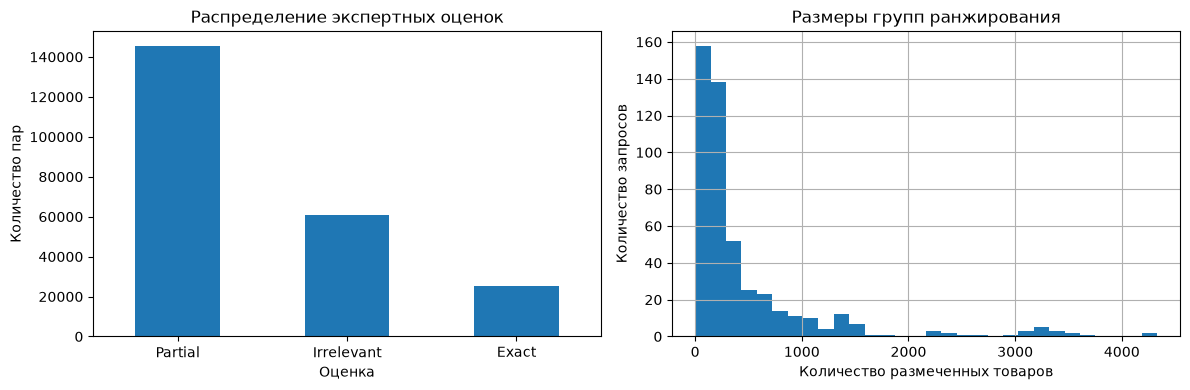

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels["label"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение экспертных оценок")
axes[0].set_xlabel("Оценка")
axes[0].set_ylabel("Количество пар")
axes[0].tick_params(axis="x", rotation=0)

group_sizes.hist(bins=30, ax=axes[1])
axes[1].set_title("Размеры групп ранжирования")
axes[1].set_xlabel("Количество размеченных товаров")
axes[1].set_ylabel("Количество запросов")

plt.tight_layout()
plt.show()


## 3. Разбиение на обучающую, валидационную и тестовую выборки

Разбиение выполняется по `query_id`, чтобы один и тот же поисковый запрос не попадал одновременно в обучение и оценку качества.


In [6]:
query_ids = queries["query_id"].to_numpy().copy()

rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(query_ids)

n_queries = len(query_ids)
n_train = int(0.70 * n_queries)
n_val = int(0.15 * n_queries)

train_query_ids = query_ids[:n_train]
val_query_ids = query_ids[n_train:n_train + n_val]
test_query_ids = query_ids[n_train + n_val:]

print("Обучающих запросов:", len(train_query_ids))
print("Валидационных запросов:", len(val_query_ids))
print("Тестовых запросов:", len(test_query_ids))


Обучающих запросов: 336
Валидационных запросов: 72
Тестовых запросов: 72


In [7]:
train_queries = set(train_query_ids)
val_queries = set(val_query_ids)
test_queries = set(test_query_ids)

assert train_queries.isdisjoint(val_queries)
assert train_queries.isdisjoint(test_queries)
assert val_queries.isdisjoint(test_queries)

## 4. Порядковое кодирование оценок

Экспертные оценки имеют естественный порядок:

`Irrelevant < Partial < Exact`

Применим порядковое кодирование (**ordinal encoding**):

- `Irrelevant` → 0
- `Partial` → 1
- `Exact` → 2

Эти значения задают порядок релевантности для LambdaMART.


In [8]:
ORDINAL_MAPPING = {
    "Irrelevant": 0,
    "Partial": 1,
    "Exact": 2,
}

labels = labels.copy()
labels["relevance"] = labels["label"].map(ORDINAL_MAPPING)

assert labels["relevance"].notna().all()


## 5. Отбор кандидатов: BM25 и семантический поиск

Первый этап поиска работает по всему каталогу товаров.

BM25 оценивает лексическое совпадение запроса с названием и классом товара. Семантический поиск использует эмбеддинги тех же текстов. Два списка объединяются с помощью **Reciprocal Rank Fusion (RRF)**, после чего для каждого запроса оставляются 300 кандидатов для переранжирования.


In [9]:
def tokenize(text):
    return re.findall(r"[a-z0-9]+", str(text).lower())


products = products.copy()
products["search_text"] = (
    products["product_name"].fillna("")
    + " "
    + products["product_class"].fillna("")
).str.strip()

product_corpus = products["search_text"].map(tokenize).tolist()
bm25 = BM25Okapi(product_corpus)


query_id_to_idx = {
    query_id: idx
    for idx, query_id in enumerate(queries["query_id"])
}

### Семантические представления

Эмбеддинги товаров и запросов сохраняются в `data/WANDS/cache/`, чтобы при повторном запуске не вычислять их заново.


In [10]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

embedding_tag = EMBEDDING_MODEL_NAME.split("/")[-1].replace("-", "_")
product_embeddings_path = CACHE_DIR / f"{embedding_tag}_products.npy"
query_embeddings_path = CACHE_DIR / f"{embedding_tag}_queries.npy"

if product_embeddings_path.exists():
    product_embeddings = np.load(product_embeddings_path)
else:
    product_embeddings = embedding_model.encode(
        products["search_text"].tolist(),
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    np.save(product_embeddings_path, product_embeddings)

if query_embeddings_path.exists():
    query_embeddings = np.load(query_embeddings_path)
else:
    query_embeddings = embedding_model.encode(
        queries["query"].tolist(),
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    np.save(query_embeddings_path, query_embeddings)

print("Product embeddings:", product_embeddings.shape)
print("Query embeddings:", query_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Product embeddings: (42994, 384)
Query embeddings: (480, 384)


In [11]:
def top_k_indices(scores, k):
    k = min(k, len(scores))

    if k == len(scores):
        return np.argsort(scores)[::-1]

    indices = np.argpartition(scores, -k)[-k:]
    return indices[np.argsort(scores[indices])[::-1]]


def retrieve_hybrid(query, query_embedding, top_n=RERANK_TOP_N):
    bm25_scores = bm25.get_scores(tokenize(query)).astype(np.float32)
    dense_scores = (product_embeddings @ query_embedding).astype(np.float32)

    bm25_idx = top_k_indices(bm25_scores, SOURCE_TOP_K)
    dense_idx = top_k_indices(dense_scores, SOURCE_TOP_K)

    bm25_rank = {int(idx): rank for rank, idx in enumerate(bm25_idx, start=1)}
    dense_rank = {int(idx): rank for rank, idx in enumerate(dense_idx, start=1)}

    candidate_idx = np.union1d(bm25_idx, dense_idx)

    rrf_scores = np.array([
        (1.0 / (RRF_K + bm25_rank[idx]) if idx in bm25_rank else 0.0)
        + (1.0 / (RRF_K + dense_rank[idx]) if idx in dense_rank else 0.0)
        for idx in candidate_idx
    ])

    order = np.argsort(rrf_scores)[::-1][:top_n]
    candidate_idx = candidate_idx[order]

    return pd.DataFrame({
        "product_id": products.iloc[candidate_idx]["product_id"].to_numpy(),
        "bm25_score": bm25_scores[candidate_idx],
        "dense_similarity": dense_scores[candidate_idx],
        "candidate_rank": np.arange(1, len(candidate_idx) + 1),
    })


## 6. Формирование выборки кандидатов и построение признаков

LambdaMART обучается только на товарах, которые прошли первый этап поиска.

Для каждого запроса берём объединённый Top-300 и присоединяем экспертные оценки WANDS. Товары без экспертной оценки не считаются нерелевантными и не используются как отрицательные примеры.

Для переранжирования используются лексические, семантические и товарные признаки.


In [12]:
hybrid_candidates_by_query = {}
candidate_parts = []

for query_id, query in queries[["query_id", "query"]].itertuples(index=False):
    query_embedding = query_embeddings[query_id_to_idx[query_id]]

    candidates = retrieve_hybrid(
        query,
        query_embedding,
        top_n=RERANK_TOP_N,
    )

    candidates.insert(0, "query_id", query_id)

    hybrid_candidates_by_query[query_id] = candidates.copy()
    candidate_parts.append(candidates)

candidate_pool = pd.concat(candidate_parts, ignore_index=True)

candidate_data = (
    candidate_pool
    .merge(
        labels[["query_id", "product_id", "label", "relevance"]],
        on=["query_id", "product_id"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        queries[["query_id", "query"]],
        on="query_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        products[
            [
                "product_id",
                "product_name",
                "product_class",
                "average_rating",
                "rating_count",
                "review_count",
            ]
        ],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
)

print("Всего кандидатов:", len(candidate_pool))
print("Кандидатов с экспертной оценкой:", len(candidate_data))
print("Доля кандидатов с оценкой:", round(len(candidate_data) / len(candidate_pool), 4))

assert candidate_data["query"].notna().all()
assert candidate_data["product_name"].notna().all()


Всего кандидатов: 144000
Кандидатов с экспертной оценкой: 78163
Доля кандидатов с оценкой: 0.5428


In [13]:
query_tokens = candidate_data["query"].map(tokenize)
product_tokens = candidate_data["product_name"].fillna("").map(tokenize)

candidate_data["token_overlap"] = [
    len(set(q_tokens) & set(p_tokens))
    for q_tokens, p_tokens in zip(query_tokens, product_tokens)
]

query_lengths = query_tokens.map(len).clip(lower=1)

candidate_data["query_coverage"] = (
    candidate_data["token_overlap"] / query_lengths
).astype(np.float32)

rating_median = products["average_rating"].median()

candidate_data["rating_value"] = (
    candidate_data["average_rating"]
    .fillna(rating_median)
    .astype(np.float32)
)

candidate_data["log_review_count"] = np.log1p(
    candidate_data["review_count"].fillna(0)
).astype(np.float32)

candidate_data["log_rating_count"] = np.log1p(
    candidate_data["rating_count"].fillna(0)
).astype(np.float32)

FEATURES = [
    "bm25_score",
    "dense_similarity",
    "token_overlap",
    "query_coverage",
    "rating_value",
    "log_review_count",
    "log_rating_count",
]

assert candidate_data[FEATURES].notna().all().all()


## 7. Отбор сложных отрицательных примеров

В качестве сложных отрицательных примеров используем товары с оценкой `Irrelevant`, которые первый этап поиска поднял в Top-300.

Все найденные `Partial` и `Exact` пары сохраняются, а количество `Irrelevant` ограничивается для каждого обучающего запроса.


In [14]:
train_candidates = candidate_data[
    candidate_data["query_id"].isin(train_query_ids)
].copy()

val_data = candidate_data[
    candidate_data["query_id"].isin(val_query_ids)
].copy()

test_data = candidate_data[
    candidate_data["query_id"].isin(test_query_ids)
].copy()

positive_pairs = train_candidates[
    train_candidates["relevance"] > 0
]

hard_negatives = (
    train_candidates[train_candidates["relevance"] == 0]
    .sort_values(["query_id", "candidate_rank"])
    .groupby("query_id", group_keys=False)
    .head(HARD_NEGATIVES_PER_QUERY)
)

train_data = pd.concat(
    [positive_pairs, hard_negatives],
    ignore_index=True,
)

print("Обучающих кандидатов с оценкой:", len(train_candidates))
print("Пар после отбора отрицательных примеров:", len(train_data))
print("Сложных отрицательных примеров:", len(hard_negatives))


Обучающих кандидатов с оценкой: 56040
Пар после отбора отрицательных примеров: 54095
Сложных отрицательных примеров: 5645


In [15]:
def keep_rankable_groups(data):
    group_stats = (
        data
        .groupby("query_id")["relevance"]
        .agg(["size", "nunique"])
    )

    valid_query_ids = group_stats[
        (group_stats["size"] >= 2)
        & (group_stats["nunique"] >= 2)
    ].index

    return data[data["query_id"].isin(valid_query_ids)].copy()


train_data = keep_rankable_groups(train_data)
val_data = keep_rankable_groups(val_data)
test_data = keep_rankable_groups(test_data)

print("Обучающих групп:", train_data["query_id"].nunique())
print("Валидационных групп:", val_data["query_id"].nunique())
print("Тестовых групп:", test_data["query_id"].nunique())


Обучающих групп: 303
Валидационных групп: 58
Тестовых групп: 65


## 8. Обучение LambdaMART

LambdaMART обучается упорядочивать товары внутри каждого поискового запроса.

Для порядковых оценок `0 / 1 / 2` задаются веса `[0, 1, 3]`, поэтому ошибка в расположении товара с оценкой `Exact` сильнее влияет на целевую метрику, чем ошибка для `Partial`.


In [16]:
def prepare_ltr_data(data):
    data = data.sort_values("query_id").reset_index(drop=True)

    group = (
        data
        .groupby("query_id", sort=False)
        .size()
        .to_numpy()
    )

    X = data[FEATURES]
    y = data["relevance"]

    assert group.sum() == len(data)

    return data, X, y, group


train_data, X_train, y_train, train_group = prepare_ltr_data(train_data)
val_data, X_val, y_val, val_group = prepare_ltr_data(val_data)


In [17]:
model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    label_gain=[0, 1, 3],
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    group=train_group,
    eval_X=X_val,
    eval_y=y_val,
    eval_group=[val_group],
    eval_at=[5, 10],
    callbacks=[
        lgb.early_stopping(75),
        lgb.log_evaluation(50),
    ],
)

print("Лучшая итерация:", model.best_iteration_)
display(model.best_score_)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1071
[LightGBM] [Info] Number of data points in the train set: 50488, number of used features: 7
Training until validation scores don't improve for 75 rounds
[50]	valid_0's ndcg@5: 0.809006	valid_0's ndcg@10: 0.798533
Early stopping, best iteration is:
[1]	valid_0's ndcg@5: 0.821117	valid_0's ndcg@10: 0.811591
Лучшая итерация: 1


defaultdict(collections.OrderedDict,
            {'valid_0': OrderedDict([('ndcg@5',
                           np.float64(0.8211171200184859)),
                          ('ndcg@10', np.float64(0.8115912710772695))])})

## 9. Оценка качества

Тестовая выборка используется только после обучения модели.

Качество отбора кандидатов оценивается через `Recall@K`: метрика показывает, какую долю известных релевантных товаров удалось сохранить после первого этапа поиска.

Качество переранжирования оценивается через `NDCG@5` и `NDCG@10` на кандидатах из Top-300, для которых есть экспертная оценка WANDS. Товары без оценки не считаются автоматически нерелевантными.


In [18]:
def build_relevant_sets(data, relevant_labels):
    return (
        data[data["label"].isin(relevant_labels)]
        .groupby("query_id")["product_id"]
        .apply(set)
    )


def recall_at_k(retrieved_ids, relevant_ids, k):
    if relevant_ids is None or len(relevant_ids) == 0:
        return np.nan

    retrieved = set(retrieved_ids[:k])
    return len(retrieved & relevant_ids) / len(relevant_ids)


retrieval_ks = (50, 100, 300)

test_labels = labels[
    labels["query_id"].isin(test_query_ids)
].copy()

test_exact = build_relevant_sets(test_labels, {"Exact"})
test_relevant = build_relevant_sets(test_labels, {"Exact", "Partial"})


In [19]:
def evaluate_retrieval(relevant_by_query):
    result = {}

    for k in retrieval_ks:
        values = []

        for query_id in test_query_ids:
            relevant_ids = relevant_by_query.get(query_id)

            if relevant_ids is None or len(relevant_ids) == 0:
                continue

            retrieved_ids = (
                hybrid_candidates_by_query[query_id]["product_id"]
                .head(k)
                .tolist()
            )

            values.append(
                recall_at_k(
                    retrieved_ids,
                    relevant_ids,
                    k,
                )
            )

        result[f"Recall@{k}"] = np.mean(values)

    result["queries"] = sum(
        relevant_by_query.get(query_id) is not None
        and len(relevant_by_query.get(query_id)) > 0
        for query_id in test_query_ids
    )

    return result


retrieval_results = pd.DataFrame(
    [
        evaluate_retrieval(test_exact),
        evaluate_retrieval(test_relevant),
    ],
    index=["Exact", "Exact + Partial"],
)

display(retrieval_results)


,Recall@50,Recall@100,Recall@300,queries
Exact,0.489472,0.582594,0.812630,58
Exact + Partial,0.233955,0.386596,0.665131,72


In [20]:
def ndcg_at_k(relevance, scores, k):
    relevance = np.asarray(relevance)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1][:k]
    ranked_relevance = relevance[order]

    gains = np.power(2.0, ranked_relevance) - 1.0
    discounts = np.log2(np.arange(2, len(ranked_relevance) + 2))
    dcg = np.sum(gains / discounts)

    ideal_relevance = np.sort(relevance)[::-1][:k]
    ideal_gains = np.power(2.0, ideal_relevance) - 1.0
    ideal_discounts = np.log2(np.arange(2, len(ideal_relevance) + 2))
    idcg = np.sum(ideal_gains / ideal_discounts)

    return dcg / idcg if idcg > 0 else np.nan


def evaluate_ranking(data, score_column):
    metrics = {
        "NDCG@5": [],
        "NDCG@10": [],
    }

    for _, group in data.groupby("query_id"):
        relevance = group["relevance"].to_numpy()
        scores = group[score_column].to_numpy()

        metrics["NDCG@5"].append(ndcg_at_k(relevance, scores, 5))
        metrics["NDCG@10"].append(ndcg_at_k(relevance, scores, 10))

    return {
        metric: np.nanmean(values)
        for metric, values in metrics.items()
    }


test_data = test_data.copy()
test_data["model_score"] = model.predict(
    test_data[FEATURES],
    num_iteration=model.best_iteration_,
)

ranking_results = pd.DataFrame(
    [evaluate_ranking(test_data, "model_score")],
    index=["Top-300 → LambdaMART"],
)

ranking_results["queries"] = test_data["query_id"].nunique()
display(ranking_results)


,NDCG@5,NDCG@10,queries
Top-300 → LambdaMART,0.710994,0.717887,65


## 10. Полный поиск

Функция принимает произвольный запрос, получает 300 кандидатов из объединённого поиска, рассчитывает признаки и переранжирует товары с помощью LambdaMART.


In [21]:
def add_inference_features(candidates, query):
    data = candidates.merge(
        products[
            [
                "product_id",
                "product_name",
                "product_class",
                "average_rating",
                "rating_count",
                "review_count",
            ]
        ],
        on="product_id",
        how="left",
        validate="one_to_one",
    )

    q_tokens = tokenize(query)
    q_token_set = set(q_tokens)
    q_len = max(len(q_tokens), 1)

    product_token_lists = data["product_name"].fillna("").map(tokenize)

    data["token_overlap"] = [
        len(q_token_set & set(tokens))
        for tokens in product_token_lists
    ]

    data["query_coverage"] = (
        data["token_overlap"] / q_len
    ).astype(np.float32)


    data["rating_value"] = (
        data["average_rating"]
        .fillna(rating_median)
        .astype(np.float32)
    )

    data["log_review_count"] = np.log1p(
        data["review_count"].fillna(0)
    ).astype(np.float32)

    data["log_rating_count"] = np.log1p(
        data["rating_count"].fillna(0)
    ).astype(np.float32)

    return data


def search(query, top_k=10):
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )[0].astype(np.float32)

    candidates = retrieve_hybrid(
        query,
        query_embedding,
        top_n=RERANK_TOP_N,
    )

    candidates = add_inference_features(candidates, query)

    candidates["model_score"] = model.predict(
        candidates[FEATURES],
        num_iteration=model.best_iteration_,
    )

    return (
        candidates
        .sort_values("model_score", ascending=False)
        .head(top_k)[
            [
                "product_id",
                "product_name",
                "product_class",
                "model_score",
                "bm25_score",
                "dense_similarity",
            ]
        ]
        .reset_index(drop=True)
    )

In [22]:
display(search("smart coffee table", top_k=10))

,product_id,product_name,product_class,model_score,bm25_score,dense_similarity
0,33698,smart coffee table with storage,Coffee & Cocktail Tables,0.052534,13.365331,0.870018
1,36192,loehr wheel coffee table with storage,Coffee & Cocktail Tables,0.010961,6.678557,0.716229
2,7763,dominique coffee table with tray top,Coffee & Cocktail Tables,0.010961,6.678557,0.716750
3,41349,iolanthe solid wood coffee table with storage,Coffee & Cocktail Tables,0.010961,6.416431,0.716290
4,35910,crazy solid coffee table,Coffee & Cocktail Tables,0.010961,7.275009,0.718419
5,5132,solid coffee table,Coffee & Cocktail Tables,0.010961,7.616540,0.733268
6,38250,seese coffee table,Coffee & Cocktail Tables,0.010961,7.616540,0.739416
7,17106,telfair sled coffee table with storage,Coffee & Cocktail Tables,0.010961,6.678557,0.718068
8,9870,fruge coffee table,Coffee & Cocktail Tables,0.010961,7.616540,0.733624
9,39692,calmar coffee table,NaN,0.010961,7.613919,0.745736


## 11. Анализ ошибок

Рассмотрим тестовые запросы с самым низким `NDCG@10`, чтобы увидеть случаи, в которых итоговое ранжирование работает хуже всего.


In [23]:
per_query_quality = []

for query_id, group in test_data.groupby("query_id"):
    per_query_quality.append({
        "query_id": query_id,
        "NDCG@10": ndcg_at_k(
            group["relevance"].to_numpy(),
            group["model_score"].to_numpy(),
            10,
        ),
        "candidates_with_labels": len(group),
    })

per_query_quality = (
    pd.DataFrame(per_query_quality)
    .merge(
        queries[["query_id", "query"]],
        on="query_id",
        how="left",
    )
    .sort_values("NDCG@10")
)

display(per_query_quality.head(10))


,query_id,NDCG@10,candidates_with_labels,query
26,141,0.117615,86,podium with locking cabinet
33,198,0.204795,82,cake plates with tops
47,314,0.333333,124,body pillow and case
59,437,0.333333,146,kitchen islands with seating
58,429,0.359844,293,gray dresser
55,402,0.384410,216,modern farmhouse lighting semi flush mount
51,325,0.391137,55,outdoor waterproof chest
4,17,0.396526,77,closet storage with zipper
31,183,0.407388,69,farmhouse bread box
27,161,0.442813,77,accent chair recliner


## 12. Итог

Построена двухэтапная система поискового ранжирования:

1. отбор кандидатов по всему каталогу с помощью BM25 и семантического поиска;
2. объединение двух списков через Reciprocal Rank Fusion;
3. формирование Top-300 кандидатов для каждого запроса;
4. отбор сложных отрицательных примеров среди найденных `Irrelevant` товаров;
5. переранжирование кандидатов с помощью LambdaMART;
6. оценка полноты первого этапа через `Recall@K`;
7. оценка качества итогового порядка через `NDCG@5/10`;
8. поиск по произвольному пользовательскому запросу.

WANDS содержит экспертные оценки только для части пар запрос–товар, поэтому товары без оценки не используются как отрицательные примеры.
